Tutorial 1: Designing a Strong Chromatin Boundary with Akita Semifreddo (SF)
=============================================================================

In this tutorial, you will learn how to use AkitaSF — a sequence design
pipeline combining the Ledidi sequence optimizer with the Semifreddo
(half-frozen) version of the AkitaV2 genome folding prediction model — to design a genomic
sequence that folds into a strong insulated chromatin boundary.

A boundary in 3D chromatin organisation corresponds to a region that
separates two topologically associating domains (TADs): contacts are
enriched within each domain and depleted across the boundary. AkitaSF
achieves this by iteratively editing the DNA sequence within a single 2 kb
central bin until the Akita model predicts a contact map that resembles a
strong boundary pattern.

─────────────────────────────────────────────────────────────────────────────
Prerequisites
─────────────────────────────────────────────────────────────────────────────

Before running this tutorial, make sure you have:

1. A working Python environment in which AkitaPT can run.      
The required packages and versions are specified in the `environment.yml`
and `requirements.txt` files provided with this repository.

2. Ledidi installed:     
`pip install ledidi`     
or cloned from [ledidi repository](https://github.com/jmschrei/ledidi) and added to `sys.path`.

3. The [akita_pytorch repository](https://github.com/PSmaruj/akita_pytorch) on your Python path.

4. A trained `AkitaPT` mouse mESC model checkpoint (.pth file)
available in the [akita_pytorch repository](https://github.com/PSmaruj/akita_pytorch).

5. The mm10 reference genome FASTA file (to download, check [here](https://genome.ucsc.edu/cgi-bin/hgGateway?db=mm10)).

All cluster-specific paths are collected in the CONFIGURATION section below —
update them to match your environment before running.

─────────────────────────────────────────────────────────────────────────────
What this tutorial covers
─────────────────────────────────────────────────────────────────────────────

Cell 1  — Imports    
Cell 2  — Configuration: paths, coordinates, hyperparameters   
Cell 3  — Generating & saving pre-computation files (sequence, tower output,
           boundary target, mask) to a local tmp_data/ directory   
Cell 4  — Inspecting the pre-computed inputs   
Cell 5  — Loading the Akita model   
Cell 6  — Building the SemifreddoLedidiWrapper and sanity-checking it   
Cell 7  — Defining the boundary loss function      
Cell 8  — Running the Ledidi optimisation    
Cell 9  — Analysing edit history and CTCF motif placement   
Cell 10 — Plotting loss curves   
Cell 11 — Reconstructing the full-length optimised sequence   
Cell 12 — Evaluating the result: Pearson R vs target   
Cell 13 — Visualising contact maps: initial / target / optimised   
Cell 14 — Cleanup: removing tmp_data/   

## Cell 1 — Imports

Standard library and third-party imports.
If any import fails, check that the package is installed and that the paths
in the CONFIGURATION cell below correctly point to your local checkouts of
`akita_pytorch`, `Ledidi`, and `akita_semifreddo`.

In [1]:
import os
import sys
import shutil

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from memelite import fimo
from pyfaidx import Fasta

# ── Point Python to AkitaPT, Ledidi, and AkitaSF ─────────────────────────────
# Update these three paths to match your local environment.
AKITA_PT_PATH  = "/path/to/akita_pytorch"          # contains akita/model.py
LEDIDI_PATH    = "/path/to/ledidi/ledidi"           # contains ledidi.py
AKITA_SF_PATH  = "/path/to/akita_semifreddo"        # contains semifreddo/ and utils/

sys.path.append(os.path.abspath(AKITA_PT_PATH))
sys.path.insert(0, LEDIDI_PATH)
sys.path.insert(0, os.path.abspath(AKITA_SF_PATH))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import SemifreddoLedidiWrapper
from semifreddo.losses import LocalL1Loss
from utils.model_utils import store_tower_output, make_target
from utils.data_utils import (
    one_hot_encode_sequence,
    from_upper_triu,
    upper_triangular_to_vector,
    fragment_indices_in_upper_triangular,
)
from utils.fimo_utils import read_meme_pwm

# Import the edit-history helpers from the boundary generation module.
sys.path.insert(0, os.path.abspath("../optimizations/boundaries/generation"))
from helper import build_edit_events, plot_edit_history

print("All imports successful.")

All imports successful.


## Cell 2 — Configuration

All user-facing settings are collected here so that the rest of the notebook
is path-free and easy to adapt.

 WHAT TO EDIT:     
- MODEL_PATH  — path to your `AkitaPT` checkpoint (`.pth`)    
- FASTA_PATH  — path to the mm10 reference FASTA    
- The genomic coordinates (CHROM / START / END) if you want to try a different sequence. Make sure the window is exactly 1,310,720 bp long(= 640 bins × 2,048 bp/bin), which is the input length expected by Akita.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_PATH = "/path/to/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
FASTA_PATH = "/path/to/mm10.fa"

PWM_PATH   = "./../data/pwm/MA0139.1.meme"

# ── Genomic locus ─────────────────────────────────────────────────────────────
# This tutorial uses a flat (featureless) region on chr5 from the mouse mESC
# fold-0 dataset as the starting sequence. A flat region is a good substrate
# for design because the initial prediction has little structure, making any
# imposed boundary pattern clearly attributable to the sequence edits.
CHROM = "chr5"
START = 97957888
END   = 99268608   # END - START = 1,310,720 bp = 640 bins × 2,048 bp/bin
STEM  = f"{CHROM}_{START}_{END}"

# ── Local working directory ───────────────────────────────────────────────────
# All pre-computed tensors are written here; removed at the end of the tutorial.
TMP_DIR = "tmp_data"

# ── Akita / Semifreddo architectural constants ────────────────────────────────
# These values are fixed by the Akita v2 model architecture and should not be
# changed unless you are using a different model.
MAP_SIZE       = 512    # number of bins in the square contact map (512 × 512)
NUM_DIAGS      = 2      # diagonals excluded from the upper-tri representation
CENTER_BIN_MAP = 256    # central bin index in the 512-bin contact map
CROPPING       = 64     # bins cropped by Akita's trunk before the head
BIN_SIZE       = 2048   # bp per bin
CONTEXT_BINS   = 5      # Semifreddo uses ±5 bins around the edited bin
N_TRIU         = 130305 # number of entries in the upper-tri contact vector

# ── Boundary target strength ──────────────────────────────────────────────────
# The boundary mask fills the off-diagonal quadrants of the contact map with
# this value. A negative value pushes inter-domain contacts down, i.e. creates
# a boundary. -0.5 is a moderate but clearly visible boundary signal.
BOUNDARY_STRENGTH = -0.5

# ── Optimisation hyperparameters ──────────────────────────────────────────────
L              = 125.0  # regularisation weight (input loss coefficient)
MAX_ITER       = 2000   # maximum number of Ledidi iterations
EARLY_STOPPING = 2000   # stop early if no improvement for this many iterations

# ── Visualisation ─────────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = "RdBu_r"

print("Configuration ready.")
print(f"  Locus  : {CHROM}:{START:,}–{END:,}  ({END - START:,} bp)")
print(f"  TMP_DIR: {TMP_DIR}/")

Configuration ready.
  Locus  : chr5:97,957,888–99,268,608  (1,310,720 bp)
  TMP_DIR: tmp_data/


## Cell 3 — Generating and saving pre-computation files
   
 AkitaSF requires four pre-computed tensors for each sequence:
 
- `X`          — one-hot encoded input sequence,  shape `(1, 4, L)`
- `tower_out`  — cached activations of Akita's convolutional tower,
 shape `(1, 128, 640)`; computing this once saves time during
 optimisation because only the central 11-bin window changes.
- `target`     — the desired output contact map (upper-tri vector),
              shape `(1, 1, N_triu)`; defined as the initial prediction plus
              the boundary mask.
- `mask`       — indices of the upper-tri entries that belong to the
               off-diagonal quadrants targeted by the boundary loss.
    
We generate all four here from scratch, print their shapes so you can see
what they look like, and save them to tmp_data/ for the rest of the tutorial.

In [3]:
os.makedirs(TMP_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# ── Load model (needed to compute tower output and target) ────────────────────
print("Loading Akita v2 model …")
model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded.\n")

# ── 1. One-hot encode the sequence ───────────────────────────────────────────
print(f"Extracting sequence {CHROM}:{START:,}–{END:,} from mm10 …")
genome  = Fasta(FASTA_PATH)
seq_str = genome[CHROM][START:END]
X_np    = one_hot_encode_sequence(seq_str)          # (4, L)  numpy array
X       = torch.tensor(X_np).to(device) # (1, 4, L)

print(f"  One-hot sequence shape : {tuple(X.shape)}")
print(f"  Each of the 4 rows encodes one nucleotide (A / C / G / T).")
print(f"  The columns are the {X.shape[-1]:,} base-pair positions in the window.\n")

SEQ_PATH   = os.path.join(TMP_DIR, f"{STEM}_X.pt")
torch.save(X.cpu(), SEQ_PATH)
print(f"  → saved to {SEQ_PATH}")

# ── 2. Cached tower output ────────────────────────────────────────────────────
print("\nComputing cached convolutional tower activations …")
TOWER_PATH = os.path.join(TMP_DIR, f"{STEM}_tower_out.pt")
store_tower_output(X, model, TOWER_PATH)            # saves (1, 128, 640) tensor
tower = torch.load(TOWER_PATH, weights_only=True).to(device)

print(f"  Tower output shape : {tuple(tower.shape)}")
print(f"  128  = number of feature channels after the convolutional tower.")
print(f"  640  = number of sequence bins in the tower output (before Akita's")
print(f"         transformer head crops it to 512 bins).\n")
print(f"  → saved to {TOWER_PATH}")

# ── 3. Boundary mask ──────────────────────────────────────────────────────────
print("\nBuilding the boundary mask …")
print(f"  Boundary strength = {BOUNDARY_STRENGTH}")
print(f"  The mask covers the off-diagonal quadrants of the {MAP_SIZE}×{MAP_SIZE}")
print(f"  contact map (bins 0–{MAP_SIZE//2 - 1} vs {MAP_SIZE//2}–{MAP_SIZE - 1}).")
print(f"  Setting these entries to {BOUNDARY_STRENGTH} suppresses inter-domain")
print(f"  contacts, which is exactly what a boundary looks like.\n")

half = MAP_SIZE // 2
matrix      = np.zeros((MAP_SIZE, MAP_SIZE))
matrix[:half, half:] = BOUNDARY_STRENGTH
matrix[half:, :half] = BOUNDARY_STRENGTH

frag_bool = np.zeros((MAP_SIZE, MAP_SIZE), dtype=bool)
frag_bool[:half, half:] = True
frag_bool[half:, :half] = True

b_vector  = torch.tensor(upper_triangular_to_vector(matrix, NUM_DIAGS)).float()
b_indices = torch.tensor(
    fragment_indices_in_upper_triangular(matrix_size=MAP_SIZE, fragment_mask=frag_bool)
)

MASK_PATH = os.path.join(TMP_DIR, "boundary_mask.pt")
torch.save(b_indices, MASK_PATH)
print(f"  Mask indices shape : {tuple(b_indices.shape)}")
print(f"  These are the {b_indices.shape[0]:,} upper-tri entries that lie in the")
print(f"  off-diagonal quadrants — i.e. the entries targeted by the loss.\n")
print(f"  → saved to {MASK_PATH}")

# ── 4. Boundary target ────────────────────────────────────────────────────────
print("\nBuilding the boundary target …")
print(f"  The target is computed as:")
print(f"    y_bar[mask_indices] = y_initial[mask_indices] + boundary_mask_values")
print(f"  i.e. we take the model's initial prediction and push the off-diagonal")
print(f"  contacts down by {abs(BOUNDARY_STRENGTH)}, leaving all other entries unchanged.\n")

target     = make_target(model, X, b_indices, b_vector, device)  # (1, 1, N_triu)
TARGET_PATH = os.path.join(TMP_DIR, f"{STEM}_target.pt")
torch.save(target, TARGET_PATH)

print(f"  Target shape : {tuple(target.shape)}")
print(f"  N_triu = {target.shape[-1]:,} entries in the upper-triangular contact vector.\n")
print(f"  → saved to {TARGET_PATH}")

print("\nAll pre-computation files saved to:", TMP_DIR)

Using device: cuda:0

Loading Akita v2 model …
Model loaded.

Extracting sequence chr5:97,957,888–99,268,608 from mm10 …
  One-hot sequence shape : (1, 4, 1310720)
  Each of the 4 rows encodes one nucleotide (A / C / G / T).
  The columns are the 1,310,720 base-pair positions in the window.

  → saved to tmp_data/chr5_97957888_99268608_X.pt

Computing cached convolutional tower activations …


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


  Tower output shape : (1, 128, 640)
  128  = number of feature channels after the convolutional tower.
  640  = number of sequence bins in the tower output (before Akita's
         transformer head crops it to 512 bins).

  → saved to tmp_data/chr5_97957888_99268608_tower_out.pt

Building the boundary mask …
  Boundary strength = -0.5
  The mask covers the off-diagonal quadrants of the 512×512
  contact map (bins 0–255 vs 256–511).
  Setting these entries to -0.5 suppresses inter-domain
  contacts, which is exactly what a boundary looks like.

  Mask indices shape : (65535,)
  These are the 65,535 upper-tri entries that lie in the
  off-diagonal quadrants — i.e. the entries targeted by the loss.

  → saved to tmp_data/boundary_mask.pt

Building the boundary target …
  The target is computed as:
    y_bar[mask_indices] = y_initial[mask_indices] + boundary_mask_values
  i.e. we take the model's initial prediction and push the off-diagonal
  contacts down by 0.5, leaving all other entrie

## Cell 4 — Inspecting the pre-computed inputs

Let's reload everything from disk (as we would in a real workflow) and have
a visual look at what we have before running the optimisation.

Loaded tensors:
  X      : (1, 4, 1310720)  — one-hot sequence
  tower  : (1, 128, 640)  — cached conv tower activations
  target : (1, 1, 130305) — boundary target (upper-tri vector)
  mask   : (65535,) — off-diagonal quadrant indices



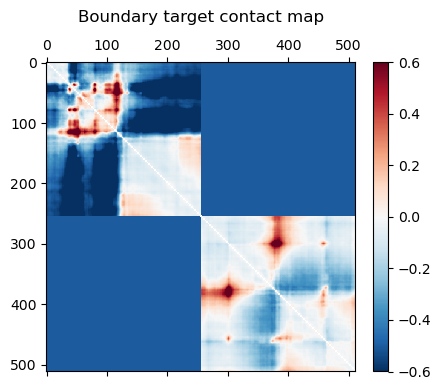

The target map shows a clear cross-shaped suppression pattern:
  • The top-right and bottom-left quadrants are pushed to negative values.
  • The diagonal blocks (within-domain contacts) are left at the initial
    prediction level — the optimiser preserves them naturally.


In [4]:
X      = torch.load(SEQ_PATH,    weights_only=True).to(device)
tower  = torch.load(TOWER_PATH,  weights_only=True).to(device)
target = torch.load(TARGET_PATH, weights_only=True).to(device)
boundary_mask = torch.load(MASK_PATH, weights_only=True).to(device)

print("Loaded tensors:")
print(f"  X      : {tuple(X.shape)}  — one-hot sequence")
print(f"  tower  : {tuple(tower.shape)}  — cached conv tower activations")
print(f"  target : {tuple(target.shape)} — boundary target (upper-tri vector)")
print(f"  mask   : {tuple(boundary_mask.shape)} — off-diagonal quadrant indices\n")

# ── Visualise the target as a 2D contact map ──────────────────────────────────
mat_target = from_upper_triu(target[0, 0, :].cpu().numpy(), matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.matshow(mat_target.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
ax.set_title("Boundary target contact map", pad=12)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("The target map shows a clear cross-shaped suppression pattern:")
print("  • The top-right and bottom-left quadrants are pushed to negative values.")
print("  • The diagonal blocks (within-domain contacts) are left at the initial")
print("    prediction level — the optimiser preserves them naturally.")

## Cell 5 — Loading the Akita model

The model was already loaded in Cell 3, but we confirm it is ready and move
it to the correct device for the optimisation.

In [5]:
model.to(device).eval()
print(f"Akita v2 model ready on device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Akita v2 model ready on device: cuda:0
Total parameters: 1,498,859


## Cell 6 — Building the SemifreddoLedidiWrapper and sanity-checking it

The `SemifreddoLedidiWrapper` wraps `AkitaPT` in a way that:

1. Accepts only the central 2,048 bp bin as input (not the full 1.3 Mb),
which makes Ledidi's gradient steps vastly cheaper.
2. Approximates the full model output by reusing the cached tower activations
from all other bins and only recomputing the transformer head on an 11-bin
(±5 context bins) window around the edited centre bin.

The sanity check below verifies that this approximation gives a Pearson R of
~1.0 against the full model for this locus.

In [6]:
sf_wrapper = SemifreddoLedidiWrapper(
    model                   = model,
    precomputed_full_output = tower,
    full_X                  = X,
    edited_bin              = CENTER_BIN_MAP,  # 256 in the 512-bin contact map
    context_bins            = CONTEXT_BINS,    # ±5 bins around centre
    cropping_applied        = CROPPING,        # 64-bin Akita trunk cropping
)

print("SemifreddoLedidiWrapper created.")
print(f"  Edited sequence slice : bp {sf_wrapper.seq_slice_start:,} – {sf_wrapper.seq_slice_end:,}")
print(f"  This is the single central 2,048 bp bin that Ledidi will optimise.")
print(f"  All other bins are held fixed via the cached tower output.\n")

# Extract the central bin slice — this is all Ledidi ever sees
X_center = X[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end]  # (1, 4, 2048)

print(f"  Central bin sequence shape : {tuple(X_center.shape)}")
print(f"    1    = batch size")
print(f"    4    = nucleotide channels (A / C / G / T)")
print(f"    2048 = base pairs in the edited bin\n")

# ── Sanity check: full model vs Semifreddo approximation ─────────────────────
print("Running sanity check: full Akita vs Semifreddo approximation …")
with torch.no_grad():
    y_full = model(X)
    y_sf   = sf_wrapper(X_center)

r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
print(f"  Pearson R (full model vs Semifreddo) : {r:.6f}")

SemifreddoLedidiWrapper created.
  Edited sequence slice : bp 645,120 – 667,648
  This is the single central 2,048 bp bin that Ledidi will optimise.
  All other bins are held fixed via the cached tower output.

  Central bin sequence shape : (1, 4, 2048)
    1    = batch size
    4    = nucleotide channels (A / C / G / T)
    2048 = base pairs in the edited bin

Running sanity check: full Akita vs Semifreddo approximation …
  Pearson R (full model vs Semifreddo) : 1.000000


## Cell 7 — Defining the boundary loss function

We use `LocalL1Loss`, which computes the L1 distance between the predicted and
target contact maps, but restricted to the entries in the boundary mask
(i.e. the off-diagonal quadrants). Entries outside the mask do not contribute
to the gradient.

The total loss minimised by Ledidi is:

`L_total = output_loss(y_pred, y_target) + λ · input_loss(x_edited, x_original)`

where `λ = L = 125.0` is the regularisation weight. The input loss penalises
edits to the sequence (L1 distance in one-hot space), encouraging Ledidi to
achieve the boundary target with as few nucleotide changes as possible.

In [7]:
local_output_loss = LocalL1Loss(boundary_mask, n_triu=N_TRIU, reduction="sum").to(device)

print("LocalL1Loss created.")
print(f"  Only the {boundary_mask.shape[0]:,} off-diagonal entries (boundary mask)")
print(f"  contribute to the output loss gradient.")
print(f"  Input regularisation weight λ = {L}")

LocalL1Loss created.
  Only the 65,535 off-diagonal entries (boundary mask)
  contribute to the output loss gradient.
  Input regularisation weight λ = 125.0


## Cell 8 — Running the Ledidi optimisation

Ledidi is an iterative, gradient-based sequence optimiser that:

1. Computes the total loss (output + regularised input) for the current
sequence.
2. Proposes nucleotide substitutions by following the gradient in one-hot
space.
3. Accepts or rejects each proposed edit based on whether it reduces the
total loss.

We pass the `SemifreddoLedidiWrapper` as the "model", so each forward pass is
~100× cheaper than running the full Akita model.

`return_history=True` records, for every accepted snapshot:
- the positions of accepted edits
- the input loss and output loss at that step
We will use this history in Cell 9 and Cell 10.

In [8]:
print("Initialising Ledidi …")
ledidi_optimizer = Ledidi(
    sf_wrapper,
    shape               = X_center.shape[1:],        # (4, 2048)
    input_loss          = torch.nn.L1Loss(reduction="sum"),
    output_loss         = local_output_loss,
    batch_size          = 1,
    l                   = L,
    max_iter            = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history      = True,
    verbose             = True,
).cuda()

print("\nStarting optimisation …")
print(f"  MAX_ITER = {MAX_ITER} | EARLY_STOPPING = {EARLY_STOPPING}")
print(f"  This may take a few minutes on CPU, or ~3 min on a GPU.\n")

generated_seq, history = ledidi_optimizer.fit_transform(X_center, target)

print("\nOptimisation complete.")
print(f"  Accepted snapshots recorded in history: {len(history['edits'])}")

Initialising Ledidi …

Starting optimisation …
  MAX_ITER = 2000 | EARLY_STOPPING = 2000
  This may take a few minutes on CPU, or ~3 min on a GPU.

iter=I	input_loss=0.0	output_loss=7.038e+04	total_loss=7.038e+04	time=0.0
iter=100	input_loss=83.0	output_loss=4.488e+04	total_loss=5.526e+04	time=7.421
iter=200	input_loss=91.0	output_loss=4.25e+04	total_loss=5.388e+04	time=7.336
iter=300	input_loss=81.0	output_loss=4.251e+04	total_loss=5.264e+04	time=7.336
iter=400	input_loss=82.0	output_loss=4.264e+04	total_loss=5.289e+04	time=7.335
iter=500	input_loss=84.0	output_loss=4.25e+04	total_loss=5.3e+04	time=7.338
iter=600	input_loss=90.0	output_loss=4.156e+04	total_loss=5.281e+04	time=7.343
iter=700	input_loss=89.0	output_loss=4.165e+04	total_loss=5.277e+04	time=7.343
iter=800	input_loss=92.0	output_loss=4.154e+04	total_loss=5.304e+04	time=7.345
iter=900	input_loss=94.0	output_loss=4.182e+04	total_loss=5.357e+04	time=7.356
iter=1000	input_loss=90.0	output_loss=4.143e+04	total_loss=5.268e+04	ti

## Cell 9 — Analysing edit history and CTCF motif placement

`build_edit_events()` walks through the sequence of accepted-edit snapshots and
labels each position as:
- 'proposed'      — newly accepted at this step
- 'accepted' — accepted in a prior step and still present

We then run FIMO to scan the final edited bin for CTCF binding motifs (JASPAR
MA0139.1). CTCF motif insertion is the dominant mechanism by which Ledidi
creates boundaries: CTCF is the main architectural protein responsible for
insulating TADs.

Edit history parsed: 2000 accepted snapshots.

Running FIMO to detect CTCF motifs in the optimised central bin …
  4 CTCF motif hit(s) found in the optimised sequence.
  Positive-strand hits (→) are shown in blue; negative-strand (←) in red.


/home1/smaruj/akita_semifreddo/optimizations/boundaries/generation/helper.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/SLURM_3137183/ipykernel_1066191/1763888508.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


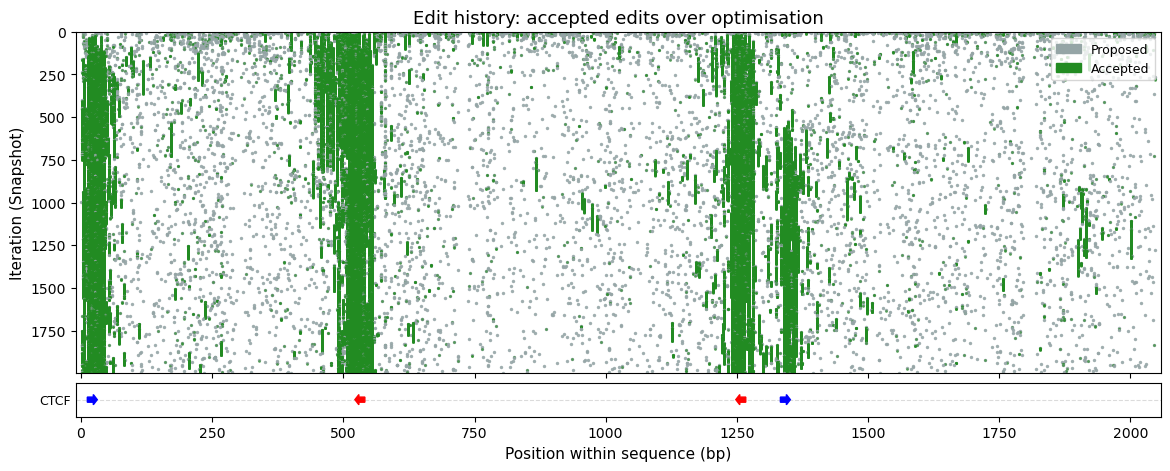


Reading the edit-history plot:
  • Each row is one accepted snapshot (time flows downward).
  • Grey dots = newly proposed edits; green dots = accepted edits.
  • Clustering of edits around CTCF arrows indicates that Ledidi is
    building a CTCF binding site to insulate the two halves of the window.


In [9]:
steps, new_pos, retained_pos = build_edit_events(history["edits"])
print(f"Edit history parsed: {len(steps)} accepted snapshots.")

pwm    = read_meme_pwm(PWM_PATH)
motifs = {"CTCF": pwm}

print("\nRunning FIMO to detect CTCF motifs in the optimised central bin …")
edited_hits = fimo(
    motifs           = motifs,
    sequences        = generated_seq.cpu().detach().numpy(),
    threshold        = 1e-4,
    reverse_complement = True,
)[0]

n_ctcf = len(edited_hits)
print(f"  {n_ctcf} CTCF motif hit(s) found in the optimised sequence.")
print(f"  Positive-strand hits (→) are shown in blue; negative-strand (←) in red.")

plot_edit_history(new_pos, retained_pos, edited_hits)
plt.tight_layout()
plt.show()

print("\nReading the edit-history plot:")
print("  • Each row is one accepted snapshot (time flows downward).")
print("  • Grey dots = newly proposed edits; green dots = accepted edits.")
print("  • Clustering of edits around CTCF arrows indicates that Ledidi is")
print("    building a CTCF binding site to insulate the two halves of the window.")

## Cell 10 — Plotting loss curves

The input loss tracks how many nucleotide changes have accumulated.
The output loss tracks how close the prediction is to the boundary target.
Both should decrease over the course of optimisation.

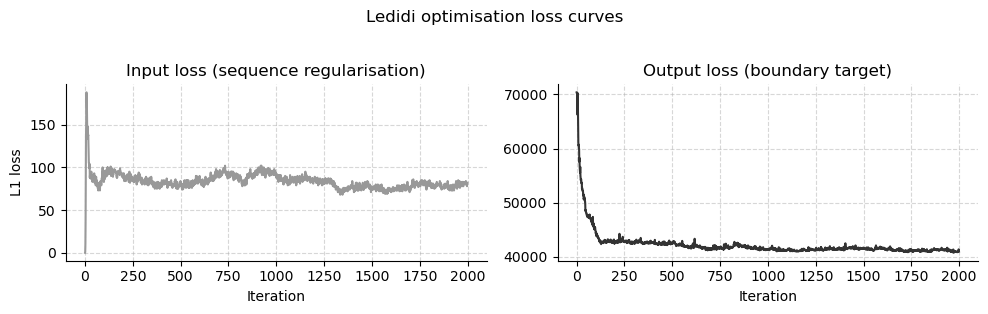

Interpreting the loss curves:
  • The input loss increases gradually as more edits are accepted;
    the regularisation weight λ keeps it from growing too fast.
  • The output loss decreases as the predicted contact map approaches
    the boundary target.
  • A plateau in both curves indicates convergence.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(history["input_loss"],  c="0.6")
axes[0].set_title("Input loss (sequence regularisation)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("L1 loss")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(history["output_loss"], c="0.2")
axes[1].set_title("Output loss (boundary target)")
axes[1].set_xlabel("Iteration")
axes[1].grid(True, linestyle="--", alpha=0.5)

sns.despine()
plt.suptitle("Ledidi optimisation loss curves", y=1.03)
plt.tight_layout()
plt.show()

print("Interpreting the loss curves:")
print("  • The input loss increases gradually as more edits are accepted;")
print("    the regularisation weight λ keeps it from growing too fast.")
print("  • The output loss decreases as the predicted contact map approaches")
print("    the boundary target.")
print("  • A plateau in both curves indicates convergence.")

## Cell 11 — Reconstructing the full-length optimised sequence

Ledidi only edited the central 2,048 bp bin. To run the full Akita model for
evaluation, we splice the edited bin back into the original 1.3 Mb sequence.

In [11]:
full_generated_seq = X.clone()
full_generated_seq[
    :, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end
] = generated_seq

n_edits = (
    torch.argmax(full_generated_seq, dim=1) != torch.argmax(X, dim=1)
).sum().item()

print(f"Number of edited nucleotides: {n_edits:,} / 2,048")
print(f"  ({100 * n_edits / BIN_SIZE:.1f}% of the central bin was changed)")
print(f"\nThe rest of the {END - START:,} bp sequence is identical to the input.")

Number of edited nucleotides: 68 / 2,048
  (3.3% of the central bin was changed)

The rest of the 1,310,720 bp sequence is identical to the input.


## Cell 12 — Evaluating the result: Pearson R vs target

We run the full Akita model on both the original and the optimised sequences
and compute the Pearson R between each prediction and the boundary target.
A well-optimised sequence should show a much higher R than the initial one.

In [12]:
model.eval()
with torch.no_grad():
    pred_optimised = model(full_generated_seq)
    pred_initial   = model(X)

r_opt,  _ = pearsonr(
    pred_optimised.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
r_init, _ = pearsonr(
    pred_initial.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)

print("Pearson R between prediction and target:")
print(f"  Initial sequence   : R = {r_init:.4f}")
print(f"  Optimised sequence : R = {r_opt:.4f}")
print()
if r_opt > r_init + 0.05:
    print("✓ The optimisation improved the boundary signal substantially.")
else:
    print("! R improvement is modest. Try increasing MAX_ITER or decreasing λ (L).")

Pearson R between prediction and target:
  Initial sequence   : R = 0.3324
  Optimised sequence : R = 0.5970

✓ The optimisation improved the boundary signal substantially.


## Cell 13 — Visualising contact maps: initial / target / optimised

We convert the upper-triangular prediction vectors back to square matrices
for display. Comparing initial, target, and optimised side by side makes it
easy to assess whether the designed sequence achieves the intended boundary
pattern.

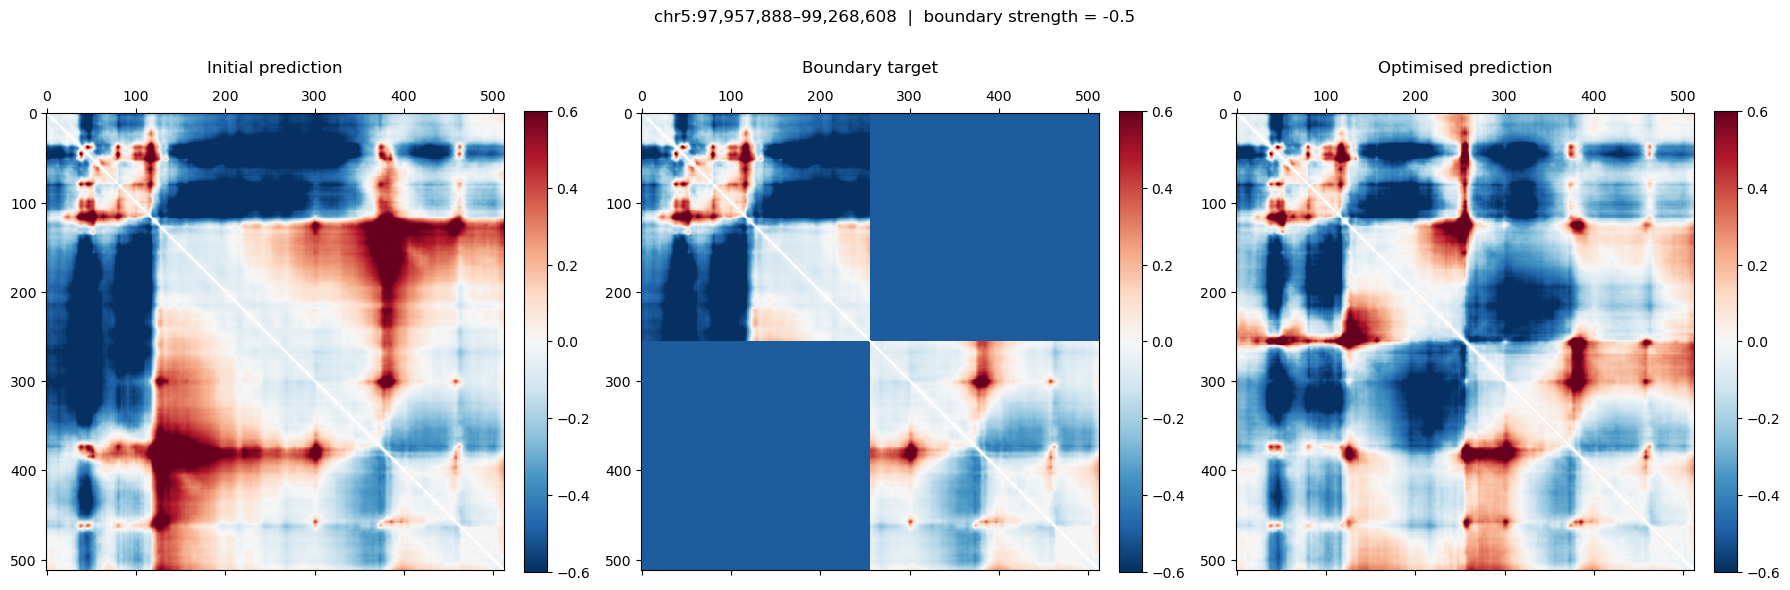

What to look for in the contact maps:
  • Initial   : roughly uniform contact enrichment — this is a flat region.
  • Target    : clear cross-shaped suppression in the off-diagonal quadrants,
                representing a strong insulated boundary at the centre.
  • Optimised : the prediction should closely match the target, with visible
                TAD-like blocks along the diagonal and a clear boundary gap.


In [13]:
mat_initial   = from_upper_triu(pred_initial[0, 0, :].cpu().numpy(),   matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
mat_optimised = from_upper_triu(pred_optimised[0, 0, :].cpu().numpy(), matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
mat_target    = from_upper_triu(target[0, 0, :].cpu().numpy(),         matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles   = ["Initial prediction", "Boundary target", "Optimised prediction"]
matrices = [mat_initial, mat_target, mat_optimised]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.matshow(mat.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_title(title, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"{CHROM}:{START:,}–{END:,}  |  boundary strength = {BOUNDARY_STRENGTH}",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("What to look for in the contact maps:")
print("  • Initial   : roughly uniform contact enrichment — this is a flat region.")
print("  • Target    : clear cross-shaped suppression in the off-diagonal quadrants,")
print("                representing a strong insulated boundary at the centre.")
print("  • Optimised : the prediction should closely match the target, with visible")
print("                TAD-like blocks along the diagonal and a clear boundary gap.")

## Cell 14 — Cleanup

Remove the `tmp_data/` directory and all files created during this tutorial.
Comment out this cell if you want to keep the tensors for further exploration.

In [14]:
shutil.rmtree(TMP_DIR)
print(f"Removed temporary directory: {TMP_DIR}/")
print()
print("─" * 70)
print("Tutorial 1 complete!")
print()
print("You have successfully:")
print("  1. Pre-computed all inputs needed for AkitaSF sequence design.")
print("  2. Built a SemifreddoLedidiWrapper for efficient optimisation.")
print("  3. Defined a boundary loss function using LocalL1Loss + a boundary mask.")
print("  4. Run Ledidi to design a sequence that folds into a strong boundary.")
print("  5. Verified that the design works by comparing predictions to the target.")
print()
print("Next steps:")
print("  • Try Tutorial 2 for a smiley face design.")
print("  • Change BOUNDARY_STRENGTH to -1.0 for a sharper boundary target.")
print("  • Swap in a different flat region (different CHROM / START / END).")
print("─" * 70)

Removed temporary directory: tmp_data/

──────────────────────────────────────────────────────────────────────
Tutorial 1 complete!

You have successfully:
  1. Pre-computed all inputs needed for AkitaSF sequence design.
  2. Built a SemifreddoLedidiWrapper for efficient optimisation.
  3. Defined a boundary loss function using LocalL1Loss + a boundary mask.
  4. Run Ledidi to design a sequence that folds into a strong boundary.
  5. Verified that the design works by comparing predictions to the target.

Next steps:
  • Try Tutorial 2 for a smiley face design.
  • Change BOUNDARY_STRENGTH to -1.0 for a sharper boundary target.
  • Swap in a different flat region (different CHROM / START / END).
──────────────────────────────────────────────────────────────────────
